In [5]:

import pandas as pd
import matplotlib.pyplot as plt


Top 10 EU countries by total rail freight (Million tonne-km):
   country  million_tkm
5       DE    1965048.0
20      PL     808877.0
11      FR     572376.0
23      SE     375355.0
0       AT     319264.0
4       CZ     256424.0
18      LV     251862.0
16      LT     223302.0
22      RO     213547.0
3       CH     184884.0


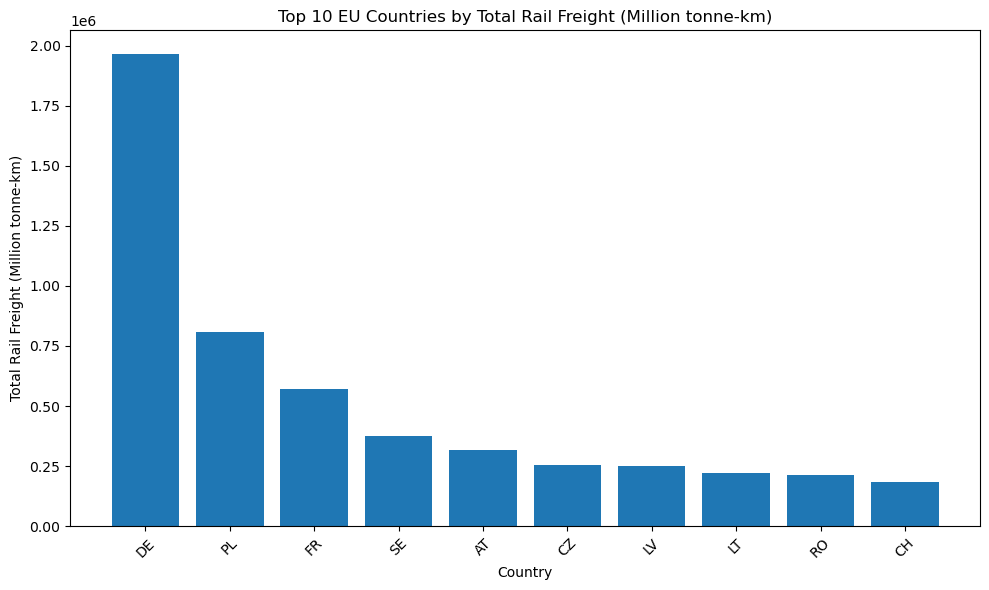

In [ ]:

# Which top and bottom 5 EU countries have the most and least train freight?
# Loading the dataset
df = pd.read_csv("../Processed/merged_eurostat_clean_V2.csv")

# Renaming columns for clarity
df = df.rename(columns={
    "geo": "country",
    "TIME_PERIOD": "year",
    "NST_TOTAL_MIO_TKM": "million_tkm"
})

# Converting freight column to numeric
df["million_tkm"] = pd.to_numeric(df["million_tkm"], errors="coerce")

# Summing total rail freight by country over all years
total_freight = df.groupby("country")["million_tkm"].sum().reset_index()

# Sorting and selecting Top 10
top10 = total_freight.sort_values(by="million_tkm", ascending=False).head(10)

print("Top 10 EU countries by total rail freight (Million tonne-km):")
print(top10)

# Plotting Top 10
plt.figure(figsize=(10,6))
plt.bar(top10["country"], top10["million_tkm"])
plt.title("Top 10 EU Countries by Total Rail Freight (Million tonne-km)")
plt.xlabel("Country")
plt.ylabel("Total Rail Freight (Million tonne-km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The bar chart shows that rail freight activity in the EU is highly concentrated among a few key countries. Germany dominates rail freight transport by a large margin, carrying nearly 2 million million tonne-km, followed by Poland and France. These three countries alone account for a substantial share of total EU rail freight, reflecting their large economies, strategic logistics hubs and strong rail infrastructure.

Sweden, Austria, Czechia, Latvia, Lithuania, Romania, and Switzerland also appear within the top 10, but with significantly smaller volumes compared to Germany. Many of these countries play vital roles in transit freight corridors, especially those positioned along major European east-west and north-south transport routes.

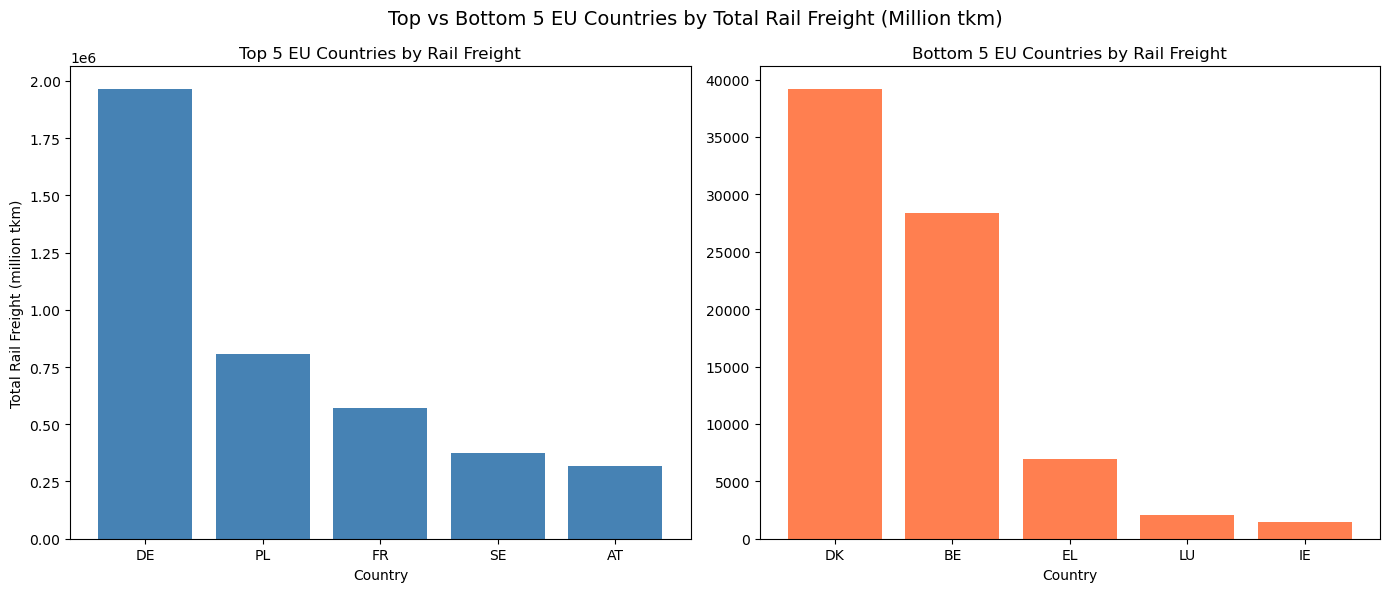


Top 5 Countries:
    country  million_tkm
5       DE    1965048.0
20      PL     808877.0
11      FR     572376.0
23      SE     375355.0
0       AT     319264.0

Bottom 5 Countries:
    country  million_tkm
6       DK      39195.0
1       BE      28395.0
8       EL       6982.0
17      LU       2105.0
14      IE       1495.0


In [ ]:
#Top vs Bottom 5 EU Countries by Rail Freight

# Top 5
top5 = total_freight.sort_values(by="million_tkm", ascending=False).head(5)

# Bottom 5 
bottom5 = (total_freight.sort_values(by="million_tkm", ascending=True).head(5).sort_values(by="million_tkm", ascending=False))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=False)

# Top 5
axes[0].bar(top5["country"], top5["million_tkm"], color="steelblue")
axes[0].set_title("Top 5 EU Countries by Rail Freight")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Total Rail Freight (million tkm)")

# Bottom 5
axes[1].bar(bottom5["country"], bottom5["million_tkm"], color="coral")
axes[1].set_title("Bottom 5 EU Countries by Rail Freight")
axes[1].set_xlabel("Country")

# Main Title
fig.suptitle("Top vs Bottom 5 EU Countries by Total Rail Freight (Million tkm)", fontsize=14)

plt.tight_layout()
plt.show()

print("\nTop 5 Countries:\n", top5)
print("\nBottom 5 Countries:\n", bottom5)

This comparison highlights the stark difference in rail freight volumes between the largest and smallest contributors in the EU rail network. Germany again stands out as the dominant player, followed by Poland, France, Sweden, and Austria. These countries have strong industrial bases, major logistics hubs, and well-developed freight rail corridors, which explains their high rail freight volumes.

In contrast, the bottom 5 countries — Denmark, Belgium, Greece, Luxembourg, and Ireland — contribute significantly less to total EU rail freight. Smaller land area, lower industrial output, limited freight-rail networks, or greater reliance on maritime/road transport can explain these low volumes. For example, Ireland’s freight rail network is minimal and largely focused on passenger transport, while Luxembourg’s small territory naturally limits freight movements

Top 5 EU Countries: ['DE', 'PL', 'FR', 'SE', 'AT']


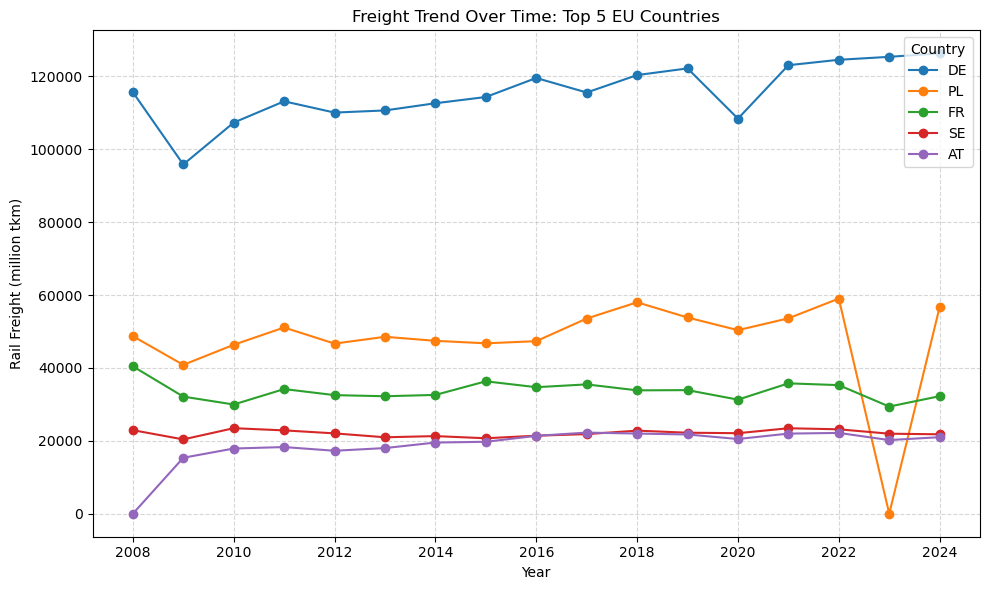

In [22]:
# Freight trend over time for Top 5 countries
# Top 5 countries
top5 = total_freight.sort_values(by="million_tkm", ascending=False).head(5)["country"].tolist()

print("Top 5 EU Countries:", top5)

# Filtering dataset for top 5
df_top5 = df[df["country"].isin(top5)]

# Grouping by year + country to get sum for each year and country
df_top5_yearly = df_top5.groupby(["year","country"])["million_tkm"].sum().reset_index()

# Plotting
plt.figure(figsize=(10,6))
for c in top5:
    sub = df_top5_yearly[df_top5_yearly["country"] == c]
    plt.plot(sub["year"], sub["million_tkm"], marker='o', label=c)

plt.title("Freight Trend Over Time: Top 5 EU Countries")
plt.xlabel("Year")
plt.ylabel("Rail Freight (million tkm)")
plt.legend(title="Country")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

This time-series chart illustrates the evolution of rail freight volumes among the top five EU rail freight countries: Germany, Poland, France, Sweden, and Austria. Across the time period, all countries show relatively stable freight flows with mild fluctuations, indicating long-term resilience in rail-based logistics.

Germany consistently dominates the EU market, maintaining the highest freight levels throughout. Its trend displays slight dips in certain years (e.g., around 2009 and 2020), reflecting broader economic shocks such as the financial crisis and the COVID-19 pandemic, but it quickly rebounds each time. Poland shows steady long-term growth, underscoring its increasing role as a key freight corridor between Western Europe and Eastern markets. France, Sweden, and Austria exhibit more stable and moderate freight volumes, reinforcing their position as established, well-integrated freight actors within the EU network.

A notable anomaly appears around 2023 for Poland, where recorded freight values drop sharply before returning to prior levels the following year. This may reflect temporary reporting anomalies or a one-year shock (e.g., energy crisis effects or border bottlenecks).

Chi-square Statistic: 15980911.611509945
p-value: 0.0


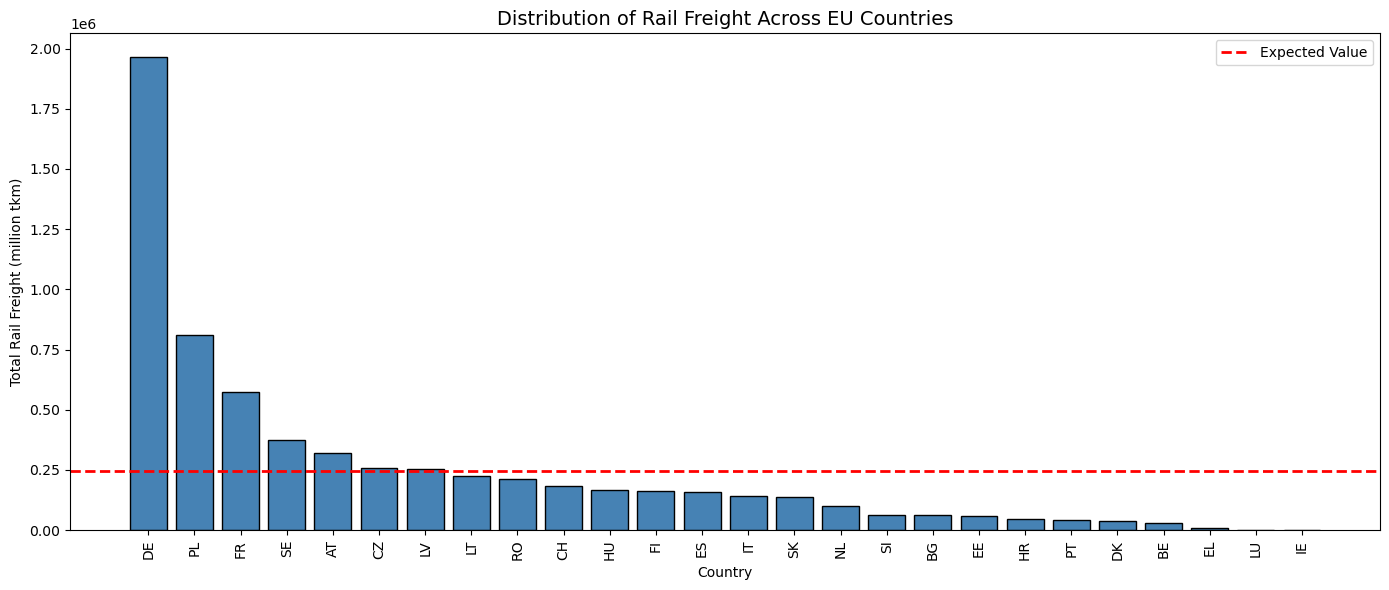

In [27]:
# Sort countries descending by total freight
total_sorted = total_by_country.sort_values(ascending=False)

# Observed + expected values
observed = total_sorted.values
expected = [observed.mean()] * len(observed)

# chi-square test on sorted data
chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-square Statistic:", chi_stat)
print("p-value:", p_value)

#plotting the distribution
plt.figure(figsize=(14,6))

plt.bar(
    total_sorted.index,
    total_sorted.values,
    color="steelblue",     # same as earlier charts
    edgecolor="black"
)

plt.axhline(
    y=observed.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Expected Value"
)

plt.title(
    "Distribution of Rail Freight Across EU Countries",
    fontsize=14
)
plt.xlabel("Country")
plt.ylabel("Total Rail Freight (million tkm)")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


This chart visualizes the total rail freight volume for each EU country, compared against an “equal-share” benchmark (red dashed line). If rail freight were evenly distributed, all countries would align near the expected value line. Instead, the bars show extreme concentration in a few economies.

Germany alone far exceeds all others, followed by Poland and France. These countries act as the core freight corridors of Europe, supported by large industrial bases, dense rail networks, and strategic transit positions. In contrast, most other EU nations fall well below the expected value line, with some—such as Luxembourg, Ireland, and Malta—contributing almost negligible volumes to the total.

The stark divergence indicates that rail freight activity in the EU is highly uneven, driven primarily by geography, economic scale, and infrastructure capacity. This observation aligns with the results of the chi-square goodness-of-fit test (p < 0.05), confirming that the distribution significantly deviates from equality.